In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
print('Libraries imported!')

Libraries imported!


In [89]:
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'

try:
    df = pd.read_csv(url)
    print('Dataset loaded!')
except:
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target
    print('Using breast cancer dataset!')

print(f'Shape: {df.shape}')
df.head()

Dataset loaded!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [90]:
print(df.info())
print(df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


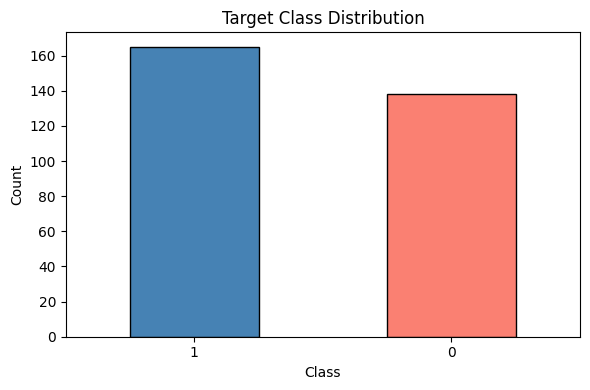

In [91]:
target_col = 'target' if 'target' in df.columns else df.columns[-1]

plt.figure(figsize=(6,4))
df[target_col].value_counts().plot(kind='bar', color=['steelblue','salmon'], edgecolor='black')
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

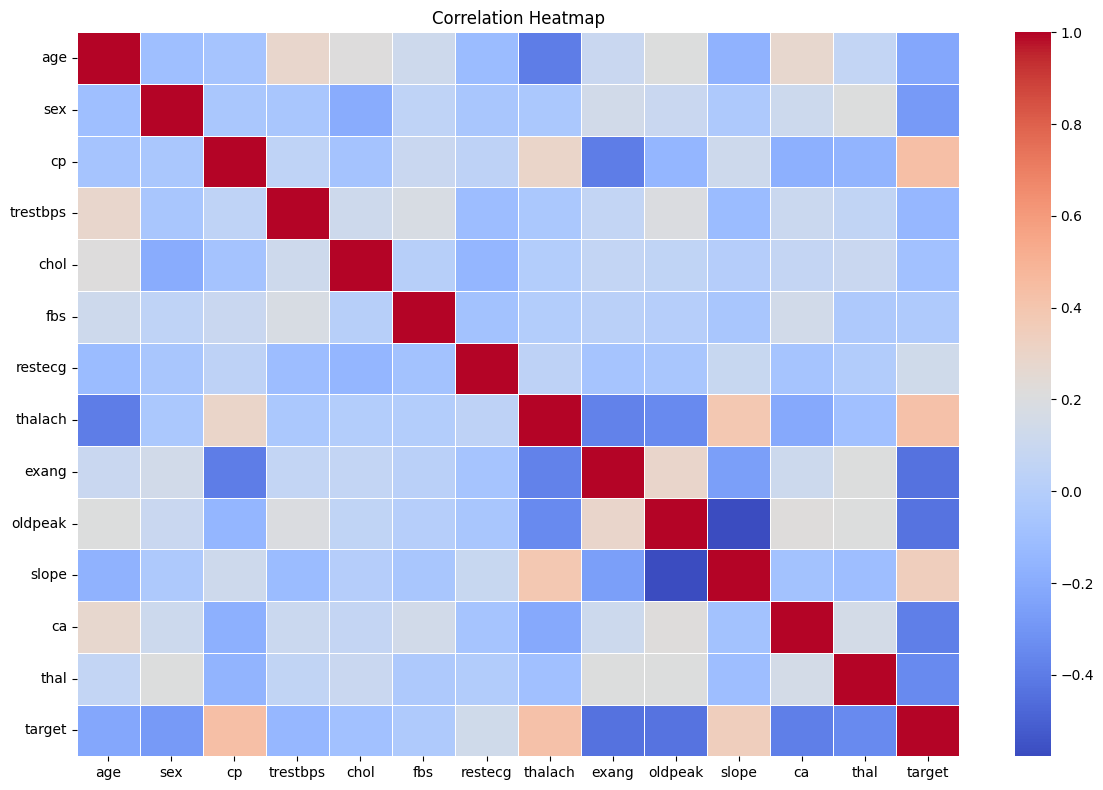

In [92]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [93]:
target_col = 'target' if 'target' in df.columns else df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 242 | Test: 61


In [94]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f'LR: {lr_acc:.4f} | DT: {dt_acc:.4f} | RF: {rf_acc:.4f}')

LR: 0.8033 | DT: 0.7869 | RF: 0.8361


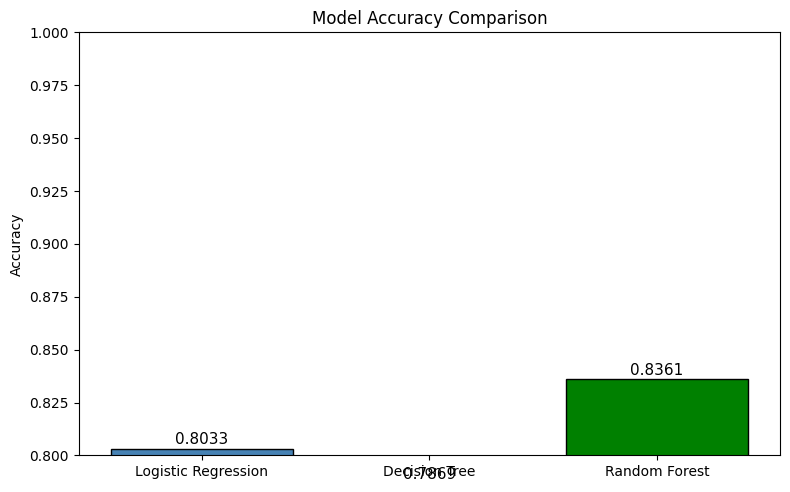

In [95]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['steelblue','orange','green'], edgecolor='black')
plt.ylim(0.8, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

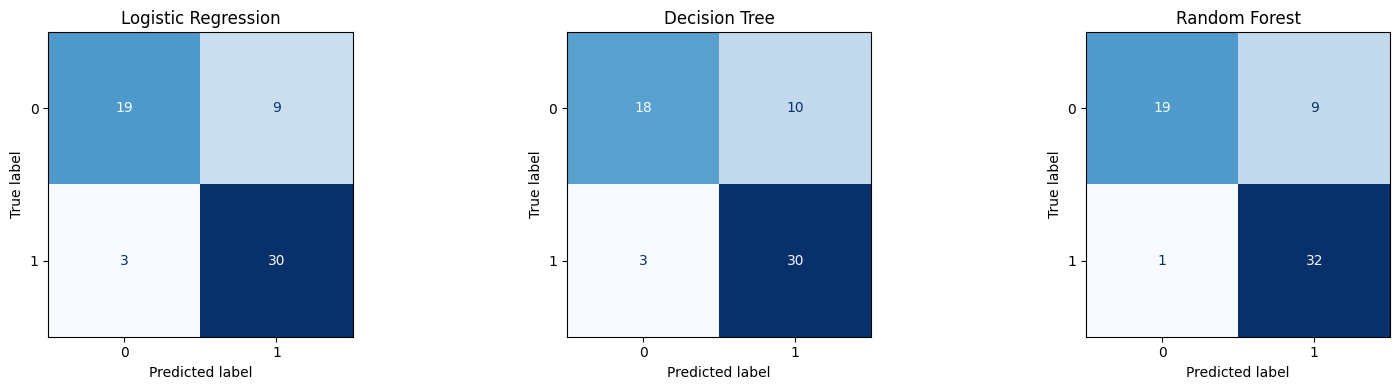

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
preds = [lr_pred, dt_pred, rf_pred]

for ax, pred, name in zip(axes, preds, models):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

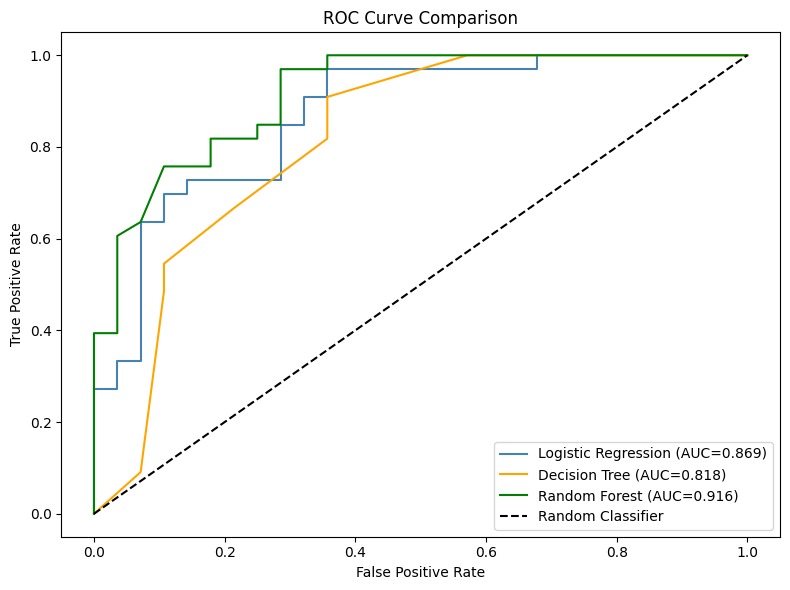

In [97]:
plt.figure(figsize=(8,6))

lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={auc(fpr,tpr):.3f})', color='steelblue')

dt_probs = dt_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, dt_probs)
plt.plot(fpr, tpr, label=f'Decision Tree (AUC={auc(fpr,tpr):.3f})', color='orange')

rf_probs = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc(fpr,tpr):.3f})', color='green')

plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

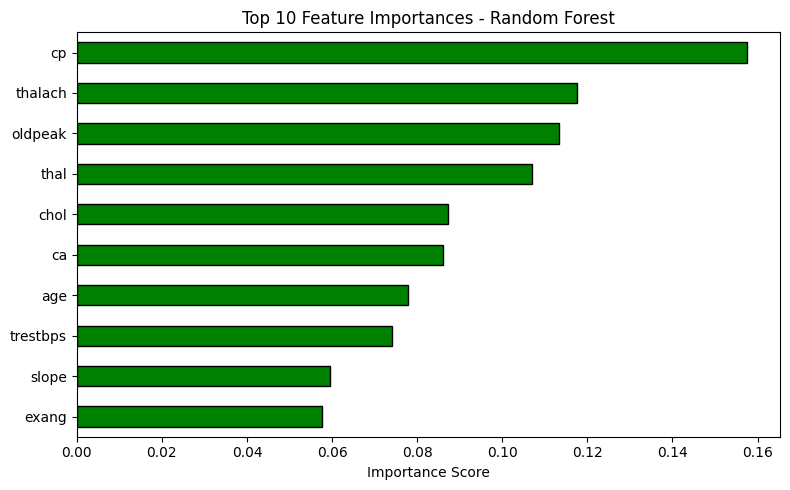

In [98]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='barh', color='green', edgecolor='black')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [99]:
summary = pd.DataFrame({
    'Model': models,
    'Accuracy': [round(a,4) for a in accuracies]
}).sort_values('Accuracy', ascending=False)

print(summary.to_string(index=False))
best = summary.iloc[0]
print(f'\nBest Model: {best["Model"]} — Accuracy: {best["Accuracy"]}')

              Model  Accuracy
      Random Forest    0.8361
Logistic Regression    0.8033
      Decision Tree    0.7869

Best Model: Random Forest — Accuracy: 0.8361
